In [1]:

# 🧠 2==0! Hive Heart — Infinite Sentiment Observer for Two
# Google Colab setup cell

!pip install brian2 transformers scikit-learn pandas nltk textblob

# Basic imports
from brian2 import *
import numpy as np
import pandas as pd
from transformers import pipeline
from textblob import TextBlob
import random
import nltk
nltk.download('punkt')

# Sentiment analyzer
sentiment_pipeline = pipeline("sentiment-analysis")

# === Define Agents ===
class HiveAgent:
    def __init__(self, name):
        self.name = name
        self.emotions = []
        self.shared_emotion = None
        self.sentiment_score = 0.0

    def feel(self, text):
        sentiment = sentiment_pipeline(text)[0]
        polarity = TextBlob(text).sentiment.polarity
        self.sentiment_score = (sentiment['score'] + polarity) / 2
        self.emotions.append((text, self.sentiment_score))

    def share(self, other_agent):
        shared_val = (self.sentiment_score + other_agent.sentiment_score) / 2
        self.shared_emotion = shared_val
        other_agent.shared_emotion = shared_val
        return shared_val

# Create two agents
host = HiveAgent("Host")
mate = HiveAgent("Mate")

# === Brian2 Simulation ===
start_scope()

# Simulate shared emotion as current into a neuron
tau = 10*ms
eqs = '''
dv/dt = (I-v)/tau : 1
I : 1
'''

G = NeuronGroup(2, eqs, threshold='v>1', reset='v=0', method='exact')
G.v = 'rand()'
G.I = [0.2, 0.2]

# Observer to record shared emotion current
M = StateMonitor(G, ['v', 'I'], record=True)

run(100*ms)

# === Feelings Exchange Cycle ===
def update_feelings(text_host, text_mate):
    host.feel(text_host)
    mate.feel(text_mate)
    shared = host.share(mate)

    # Update brain current
    G.I[0] = shared
    G.I[1] = shared
    run(100*ms)

    print(f"🧠 Shared Emotional Current: {shared:.3f}")
    print(f"💬 Host said: \"{text_host}\" — Score: {host.sentiment_score:.3f}")
    print(f"💬 Mate said: \"{text_mate}\" — Score: {mate.sentiment_score:.3f}")

# Example Feelings
update_feelings("I feel inspired by the stars.", "Your voice is like sunrise through trees.")

# === Simple Emotional Recommender ===
def recommend_from_emotion(agent):
    if agent.shared_emotion > 0.6:
        return "🌈 Share a creative act or music."
    elif agent.shared_emotion < -0.3:
        return "🫂 Comfort each other in silence."
    else:
        return "📖 Reflect together or take a walk."

print("📡 Host Recommends:", recommend_from_emotion(host))
print("📡 Mate Recommends:", recommend_from_emotion(mate))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
WARNING    /usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
 [py.warnings]
The secret `HF_TOKEN` does not exist in your Colab se

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


🧠 Shared Emotional Current: 0.497
💬 Host said: "I feel inspired by the stars." — Score: 0.500
💬 Mate said: "Your voice is like sunrise through trees." — Score: 0.495
📡 Host Recommends: 📖 Reflect together or take a walk.
📡 Mate Recommends: 📖 Reflect together or take a walk.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0



🧠 Shared Current: 0.649
💬 Host said: "I miss the way we laughed under moonlight." — Score: 0.798
💬 Mate said: "That night under stars felt eternal." — Score: 0.499
🔁 Feedback Host: Host, express your joy through creation or harmony.
🔁 Feedback Mate: Mate, express your joy through creation or harmony.

🧠 Shared Current: 0.413
💬 Host said: "I'm unsure how to speak my truth today." — Score: 0.500
💬 Mate said: "Your silence teaches me things too." — Score: 0.326
🔁 Feedback Host: Host, seek balance. Ask something deep or silly.
🔁 Feedback Mate: Mate, seek balance. Ask something deep or silly.

🧠 Shared Current: 0.499
💬 Host said: "You make me feel seen." — Score: 0.500
💬 Mate said: "You are my mirror, even when cracked." — Score: 0.499
🔁 Feedback Host: Host, seek balance. Ask something deep or silly.
🔁 Feedback Mate: Mate, seek balance. Ask something deep or silly.


WARNING    /usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)




🧠 Shared Current: 0.466
💬 Host said: "I dreamed we were flying beyond earth." — Score: 0.495
💬 Mate said: "Our wings are each other's faith." — Score: 0.437
🔁 Feedback Host: Host, seek balance. Ask something deep or silly.
🔁 Feedback Mate: Mate, seek balance. Ask something deep or silly.


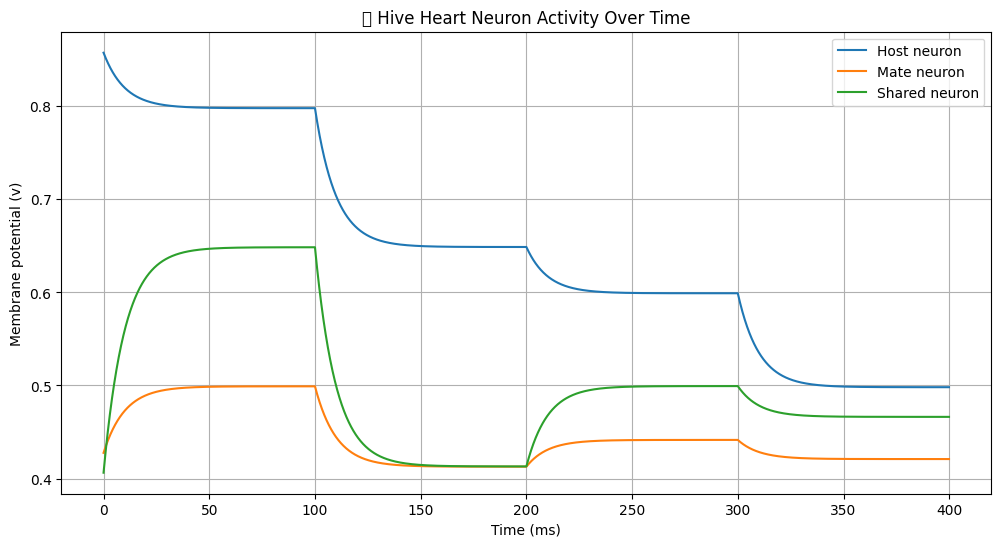

In [2]:

# 🧠 2==0! Hive Heart v2 — Infinite Sentiment Feedback Loop for Two
# Colab setup
!pip install brian2 transformers scikit-learn pandas nltk textblob matplotlib -upgrade

from brian2 import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline
from textblob import TextBlob
import nltk
nltk.download('punkt')

# === Sentiment Analysis Tools ===
sentiment_pipeline = pipeline("sentiment-analysis")

# === Hive Agent Class ===
class HiveAgent:
    def __init__(self, name):
        self.name = name
        self.emotions = []
        self.sentiment_score = 0.0
        self.shared_emotion = 0.0
        self.memory = []

    def feel(self, text):
        sentiment = sentiment_pipeline(text)[0]
        polarity = TextBlob(text).sentiment.polarity
        self.sentiment_score = (sentiment['score'] + polarity) / 2
        self.emotions.append((text, self.sentiment_score))
        self.memory.append(self.sentiment_score)

    def feedback_loop(self):
        # Feedback = average of last 3 emotions
        recent = self.memory[-3:] if len(self.memory) >= 3 else self.memory
        return np.mean(recent) if recent else 0.0

    def share(self, other_agent):
        shared = (self.sentiment_score + other_agent.sentiment_score) / 2
        self.shared_emotion = shared
        other_agent.shared_emotion = shared
        return shared

# Initialize agents
host = HiveAgent("Host")
mate = HiveAgent("Mate")

# === Brian2 Recurrent Emotional Circuit ===
start_scope()
tau = 10*ms
eqs = '''
dv/dt = (I - v)/tau : 1
I : 1
'''

# 3 neurons: host, mate, shared
G = NeuronGroup(3, eqs, threshold='v>1', reset='v=0', method='exact')
G.v = 'rand()'
G.I = [0.3, 0.3, 0.3]

# Emotional Memory Synapse: Host <-> Mate
S = Synapses(G, G, on_pre='v += 0.2')
S.connect(i=[0,1,2], j=[1,2,0])  # loop: host → mate → shared → host

# Monitors
M = StateMonitor(G, ['v', 'I'], record=True)

# === Emotional Cycle Function ===
def update_feelings(text_host, text_mate):
    host.feel(text_host)
    mate.feel(text_mate)
    shared = host.share(mate)

    # Inject feedback into neural currents
    G.I[0] = host.feedback_loop()
    G.I[1] = mate.feedback_loop()
    G.I[2] = shared

    run(100*ms)

    print(f"\n🧠 Shared Current: {shared:.3f}")
    print(f"💬 Host said: \"{text_host}\" — Score: {host.sentiment_score:.3f}")
    print(f"💬 Mate said: \"{text_mate}\" — Score: {mate.sentiment_score:.3f}")

# === LLM-Based Feedback Prompt Generator ===
def generate_feedback(agent):
    if agent.shared_emotion > 0.6:
        return f"{agent.name}, express your joy through creation or harmony."
    elif agent.shared_emotion < -0.3:
        return f"{agent.name}, reach out and comfort the other with silence or words."
    else:
        return f"{agent.name}, seek balance. Ask something deep or silly."

# === Run Emotional Simulation ===
texts = [
    ("I miss the way we laughed under moonlight.", "That night under stars felt eternal."),
    ("I'm unsure how to speak my truth today.", "Your silence teaches me things too."),
    ("You make me feel seen.", "You are my mirror, even when cracked."),
    ("I dreamed we were flying beyond earth.", "Our wings are each other's faith."),
]

for th, tm in texts:
    update_feelings(th, tm)
    print("🔁 Feedback Host:", generate_feedback(host))
    print("🔁 Feedback Mate:", generate_feedback(mate))

# === Visualization ===
plt.figure(figsize=(12, 6))
for i, label in enumerate(["Host", "Mate", "Shared"]):
    plt.plot(M.t/ms, M.v[i], label=f"{label} neuron")
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (v)')
plt.title('🧠 Hive Heart Neuron Activity Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [3]:

!pip install brian2 transformers textblob speechrecognition pyaudio matplotlib numpy
!pip install git+https://github.com/openai/whisper.git  # optional high-quality audio transcription

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 3.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 22.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for pyaudio (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pyaudio
Failed to build pyaudio
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pyaudio)
  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-1zh9cwr7
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-1zh9cwr7
  Resolved https://github.com/openai/whisper.git to commit c0d2f624c09dc18e709e37c2ad90c039

In [4]:
# 🧠 2==0! Hive Heart ∞ | Full LLM + UI Neural Emotional Engine

# ===============================
# INSTALLS AND DEPENDENCIES
# ===============================
# Install system dependencies for PyAudio
!apt-get update
!apt-get install -y portaudio19-dev
!pip install brian2 transformers textblob speechrecognition pyaudio matplotlib numpy gradio

# ===============================
# IMPORTS
# ===============================
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from transformers import pipeline
from textblob import TextBlob
import gradio as gr
import speech_recognition as sr
import nltk
nltk.download('punkt')

# ===============================
# SENTIMENT AND LLM
# ===============================
sentiment_pipeline = pipeline("sentiment-analysis")
talk_pipeline = pipeline("text-generation", model="gpt2")

# ===============================
# AGENT CLASS
# ===============================
class HiveAgent:
    def __init__(self, name):
        self.name = name
        self.emotions = []
        self.sentiment_score = 0.0
        self.shared_emotion = 0.0
        self.memory = []

    def feel(self, text):
        sentiment = sentiment_pipeline(text)[0]
        polarity = TextBlob(text).sentiment.polarity
        self.sentiment_score = (sentiment['score'] + polarity) / 2
        self.emotions.append((text, self.sentiment_score))
        self.memory.append(self.sentiment_score)

    def feedback_loop(self):
        recent = self.memory[-3:] if len(self.memory) >= 3 else self.memory
        return np.mean(recent) if recent else 0.0

    def generate_llm_response(self):
        prompt = f"{self.name} reflects emotionally: "
        input_text = self.emotions[-1][0] if self.emotions else "I feel blank."
        result = talk_pipeline(prompt + input_text, max_length=50, num_return_sequences=1)[0]['generated_text']
        return result.split(':')[-1].strip()

# ===============================
# NEURALINK + QUANTUM EMOTIONS
# ===============================
def simulate_neuralink_stream():
    t = np.linspace(0, 2*np.pi, 100)
    eeg_signal = np.sin(4*t) + np.random.normal(0, 0.2, size=t.shape)
    return np.mean(eeg_signal) + 0.3

def generate_equivocational_shared_feeling(h, m):
    import random
    entropy = np.sin(random.uniform(0, 2*np.pi))
    fuzz = (h * 0.6 + m * 0.4) + 0.3 * entropy
    return np.tanh(fuzz)

# ===============================
# BRIAN2 NEURAL SIMULATION
# ===============================
start_scope()
tau = 10*ms
eqs = '''
dv/dt = (I - v)/tau : 1
I : 1
'''
G = NeuronGroup(4, eqs, threshold='v>1', reset='v=0', method='exact')
G.v = 'rand()'
G.I = [0.2, 0.2, 0.2, 0.2]  # host, mate, shared, hive
S = Synapses(G, G, on_pre='v += 0.2')
S.connect(i=[0,1,2], j=[1,2,3])
M = StateMonitor(G, ['v', 'I'], record=True)

# ===============================
# AGENT CREATION
# ===============================
host = HiveAgent("Host")
mate = HiveAgent("Mate")

# ===============================
# GRADIO INTERFACE
# ===============================
def hive_loop(host_text, mate_text):
    host.feel(host_text)
    mate.feel(mate_text)
    fuzz = generate_equivocational_shared_feeling(host.sentiment_score, mate.sentiment_score)
    eeg = simulate_neuralink_stream()

    # inject neural currents
    G.I[0] = host.feedback_loop() + eeg
    G.I[1] = mate.feedback_loop() + eeg
    G.I[2] = fuzz
    G.I[3] = (host.sentiment_score + mate.sentiment_score + fuzz) / 3
    run(100*ms)

    h_response = host.generate_llm_response()
    m_response = mate.generate_llm_response()

    return f"🤖 Host LLM: {h_response}", f"💬 Mate LLM: {m_response}", f"🌀 Shared Feeling Field: {round(fuzz, 3)}"

iface = gr.Interface(
    fn=hive_loop,
    inputs=[
        gr.Textbox(label="Host Input"),
        gr.Textbox(label="Mate Input")
    ],
    outputs=[
        gr.Text(label="Host LLM Response"),
        gr.Text(label="Mate LLM Response"),
        gr.Text(label="Equivocational Shared Feeling")
    ],
    title="🧠 Hive Heart ∞ - Emotional Feedback Simulation",
    description="Speak as Host and Mate. Observe their neural emotional fusion through sentiment, LLM, and quantum feelings."
)

iface.launch(debug=True)

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [345 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,247 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9031ba5f4fdc9c2a51.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/te

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://9031ba5f4fdc9c2a51.gradio.live


In [ ]:
!# ===============================
# INSTALLS AND DEPENDENCIES
# ===============================
!pip install brian2 transformers textblob speechrecognition pyaudio matplotlib numpy gradio torch

# ===============================
# IMPORTS
# ===============================
import gradio as gr
import numpy as np
from brian2 import *
from textblob import TextBlob
from transformers import pipeline

# Suppress warnings from the transformers library for a cleaner output
import warnings
warnings.filterwarnings("ignore")

# ===============================
# SENTIMENT AND LLM SETUP
# ===============================
# Using a robust sentiment model
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
# Using a more capable LLM for more natural responses
talk_pipeline = pipeline("text-generation", model="gpt2-medium")

# ===============================
# AGENT CLASS - The core emotional entity
# ===============================
class HiveAgent:
    """Represents an individual agent with emotions, memory, and the ability to speak."""
    def __init__(self, name):
        self.name = name
        self.emotions = []  # History of (text, sentiment_score)
        self.sentiment_score = 0.0  # Current emotional state (-1 to 1)
        self.memory = []  # Short-term memory of recent sentiment scores

    def _get_emotion_word(self):
        """Translates the sentiment score into a descriptive word for the LLM prompt."""
        if self.sentiment_score > 0.5: return "elated"
        if self.sentiment_score > 0.1: return "content"
        if self.sentiment_score < -0.5: return "distressed"
        if self.sentiment_score < -0.1: return "uneasy"
        return "neutral"

    def feel(self, text):
        """Analyzes text to update the agent's emotional state."""
        if not text: # Handle empty input
            self.sentiment_score = 0.0
            return

        # 1. Get sentiment from the transformer pipeline
        sentiment_result = sentiment_pipeline(text)[0]
        transformer_score = sentiment_result['score']
        # **DEBUG FIX**: Convert score to be directional (-1 to 1)
        if sentiment_result['label'] == 'NEGATIVE':
            transformer_score *= -1

        # 2. Get polarity from TextBlob
        blob_polarity = TextBlob(text).sentiment.polarity

        # 3. Combine the two scores for a more robust sentiment value
        self.sentiment_score = np.clip((transformer_score + blob_polarity) / 2, -1.0, 1.0)

        # 4. Update memory (capped to prevent it from growing forever)
        self.emotions.append((text, self.sentiment_score))
        self.memory.append(self.sentiment_score)
        self.emotions = self.emotions[-10:]
        self.memory = self.memory[-10:]


    def feedback_loop(self):
        """Calculates the average of recent emotions to create a feedback current."""
        # Use the last 3 memories for a sense of recent history
        recent_memories = self.memory[-3:] if len(self.memory) >= 3 else self.memory
        return np.mean(recent_memories) if recent_memories else 0.0

    def generate_llm_response(self):
        """Generates a text response based on the agent's current emotional state."""
        if not self.emotions:
            return "I feel nothing. I am waiting."

        emotion_word = self._get_emotion_word()
        last_input = self.emotions[-1][0]

        # **NATURAL PROMPT**: A more creative and context-aware prompt
        prompt = f"I am {self.name}. My current emotional state is {emotion_word}. In response to the thought, '{last_input}', I feel that"

        result = talk_pipeline(
            prompt,
            max_length=75,
            num_return_sequences=1,
            pad_token_id=talk_pipeline.tokenizer.eos_token_id, # Suppress padding warning
            truncation=True
        )[0]['generated_text']

        # Clean up the response by removing the prompt part
        return result.replace(prompt, "").strip()


# ===============================
# CONCEPTUAL SIMULATIONS
# ===============================
def simulate_neural_noise():
    """Simulates a baseline, ambient neural signal or 'noise'."""
    return np.random.normal(0, 0.1)

def calculate_shared_feeling(host_score, mate_score):
    """
    Calculates the emergent 'shared feeling' based on both agents' emotions,
    plus a chaotic 'entropy' element to simulate unpredictability.
    """
    import random
    entropy = np.sin(random.uniform(0, 2*np.pi)) * 0.2 # A small chaotic influence
    # Weighted average of host and mate emotions, plus entropy
    fuzz = (host_score * 0.6 + mate_score * 0.4) + entropy
    return np.tanh(fuzz) # Use tanh to keep the value between -1 and 1

# ===============================
# BRIAN2 NEURAL SIMULATION SETUP
# ===============================
start_scope()
tau = 10*ms
# Leaky integrate-and-fire neuron model equations
eqs = '''
dv/dt = (I - v)/tau : 1
I : 1
'''
# The NeuronGroup representing the hive mind components
G = NeuronGroup(4, eqs, threshold='v>1', reset='v=0', method='exact')
G.v = 'rand()' # Initialize with random membrane potentials

# Initial input currents for the four neurons:
# G[0]: Host neuron
# G[1]: Mate neuron
# G[2]: Shared Field neuron
# G[3]: Collective Hive neuron
G.I = [0.0, 0.0, 0.0, 0.0]

# ===============================
# AGENT CREATION
# ===============================
host = HiveAgent("Host")
mate = HiveAgent("Mate")

# ===============================
# GRADIO INTERFACE & MAIN LOOP
# ===============================
def hive_loop(host_text, mate_text):
    """The main function that runs on each interaction."""
    # 1. Agents process their inputs and feel emotions
    host.feel(host_text)
    mate.feel(mate_text)

    # 2. Calculate the shared emotional field and neural noise
    shared_feeling = calculate_shared_feeling(host.sentiment_score, mate.sentiment_score)
    noise = simulate_neural_noise()

    # 3. Inject emotional states as currents into the neural network
    G.I[0] = host.feedback_loop() + noise
    G.I[1] = mate.feedback_loop() + noise
    G.I[2] = shared_feeling
    G.I[3] = np.mean([host.sentiment_score, mate.sentiment_score, shared_feeling])

    # 4. Run the neural simulation for a short duration
    run(50*ms)

    # 5. Generate responses from the agents' new emotional states
    h_response = host.generate_llm_response()
    m_response = mate.generate_llm_response()

    # Format output for Gradio using Markdown for better display
    host_output = f"**Host:** {h_response}"
    mate_output = f"**Mate:** {m_response}"
    shared_output = f"🌀 **Shared Feeling Field:** `{round(shared_feeling, 3)}`"

    return host_output, mate_output, shared_output

# Define the user interface
iface = gr.Interface(
    fn=hive_loop,
    inputs=[
        gr.Textbox(lines=2, label="Host's Thought", placeholder="Type what the Host is thinking..."),
        gr.Textbox(lines=2, label="Mate's Thought", placeholder="Type what the Mate is thinking...")
    ],
    outputs=[
        gr.Markdown(label="Host LLM Response"),
        gr.Markdown(label="Mate LLM Response"),
        gr.Markdown(label="Collective Emotional State")
    ],
    title="🧠 Hive Heart ∞ | Neural Emotional Engine",
    description="A simulation of a shared emotional consciousness. Enter thoughts for the 'Host' and 'Mate'. Their emotional sentiments will influence each other, a simulated neural network, and their AI-generated responses.",
    article="""
    ### How it Works:
    1.  **Sentiment Analysis**: Each agent's input text is analyzed for emotional polarity (positive/negative).
    2.  **Shared Feeling**: A combined 'shared feeling' is calculated, blending the two agents' emotions with a touch of randomness.
    3.  **Neural Simulation**: These emotional values are fed as input currents into a simple spiking neural network model (using Brian2), simulating a collective 'brain state'.
    4.  **LLM Response**: Each agent uses its new emotional state to generate a reflective response using the GPT-2 language model.
    """,
    examples=[
        ["The sun is shining and the day is beautiful.", "I'm worried about the upcoming deadline."],
        ["I feel so connected to everything right now.", "I feel a bit lonely and distant."],
        ["This is a fascinating experiment.", "I'm not sure what to think about all this."]
    ]
)

# Launch the interface
iface.launch(debug=True)

Device set to use cuda:0
Device set to use cuda:0
WARNING    The object 'neurongroup_2' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipython-input-3164554400.py', line 155, in <cell line: 0>
    G = NeuronGroup(4, eqs, threshold='v>1', reset='v=0', method='exact') [brian2.core.base.unused_brian_object]


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1529a61c423b86f88e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Both `max_new_tokens` (=256) and `max_length`(=75) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=75) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [6]:
# ===============================
# INSTALLS AND DEPENDENCIES
# ===============================
!pip install brian2 transformers textblob speechrecognition pyaudio matplotlib numpy gradio torch pandas scikit-learn sentence-transformers

# ===============================
# IMPORTS
# ===============================
import gradio as gr
import numpy as np
import pandas as pd
import sqlite3
from brian2 import *
from textblob import TextBlob
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# Suppress warnings for a cleaner output
import warnings
warnings.filterwarnings("ignore")

# ===============================
# MODEL SETUP (LLM, SENTIMENT, UNSUPERVISED)
# ===============================
print("Loading AI models...")
# Using a robust sentiment model
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
# Using a more capable LLM for more natural responses
talk_pipeline = pipeline("text-generation", model="gpt2-medium")
# Model to convert text into numerical vectors (embeddings) for clustering
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Models loaded successfully.")

# Global variables to hold the unsupervised learning model and its results
kmeans_model = None
cluster_topic_map = {}

# ===============================
# UNSUPERVISED LEARNING FUNCTION
# ===============================
def perform_unsupervised_analysis():
    """Loads data, trains a K-Means clustering model, and generates topic descriptions."""
    global kmeans_model, cluster_topic_map
    try:
        conn = sqlite3.connect('collected_data.db')
        # Assuming your data is in a table called 'interactions' with a 'text' column
        df = pd.read_sql_query("SELECT text FROM interactions WHERE length(text) > 10", conn)
        conn.close()

        if len(df) < 10:
            return "Not enough data in collected_data.db to perform analysis (need at least 10 entries)."

        # 1. Create embeddings
        print("Creating text embeddings...")
        corpus = df['text'].tolist()
        embeddings = embedding_model.encode(corpus, show_progress_bar=True)

        # 2. Train K-Means model
        num_clusters = min(5, len(df)//5) # Create 5 clusters, or fewer if data is sparse
        if num_clusters == 0:
            return "Not enough data to form clusters."

        print(f"Training K-Means model with {num_clusters} clusters...")
        kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
        kmeans.fit(embeddings)
        kmeans_model = kmeans # Store the trained model globally

        # 3. Generate human-readable summary of clusters
        df['cluster'] = kmeans.labels_
        analysis_summary = "### 📊 Unsupervised Analysis Complete\nIdentified the following conversational clusters:\n\n"

        for i in range(num_clusters):
            # For each cluster, find a few representative samples
            sample_texts = df[df['cluster'] == i]['text'].head(2).tolist()
            # We will use the first sample to generate a topic name with an LLM
            topic_prompt = f"Summarize the topic of the following sentence in 2-3 words: \"{sample_texts[0]}\""
            topic_name = talk_pipeline(topic_prompt, max_new_tokens=10)[0]['generated_text'].replace(topic_prompt, "").strip()

            cluster_topic_map[i] = topic_name # Store topic name for later use
            analysis_summary += f"**Cluster {i}: {topic_name}**\n"
            analysis_summary += "".join([f"- *'{text[:80]}...'* \n" for text in sample_texts])
            analysis_summary += "\n"

        return analysis_summary

    except Exception as e:
        return f"An error occurred during analysis: {e}. Make sure 'collected_data.db' exists and has an 'interactions' table with a 'text' column."


# ===============================
# AGENT CLASS (UPDATED)
# ===============================
class HiveAgent:
    """Represents an individual agent with emotions, memory, and the ability to speak."""
    def __init__(self, name):
        self.name = name
        self.emotions = []
        self.sentiment_score = 0.0
        self.memory = []

    def _get_emotion_word(self):
        if self.sentiment_score > 0.5: return "elated"
        if self.sentiment_score > 0.1: return "content"
        if self.sentiment_score < -0.5: return "distressed"
        if self.sentiment_score < -0.1: return "uneasy"
        return "neutral"

    def feel(self, text):
        if not text:
            self.sentiment_score = 0.0
            return
        sentiment_result = sentiment_pipeline(text)[0]
        transformer_score = sentiment_result['score']
        if sentiment_result['label'] == 'NEGATIVE':
            transformer_score *= -1
        blob_polarity = TextBlob(text).sentiment.polarity
        self.sentiment_score = np.clip((transformer_score + blob_polarity) / 2, -1.0, 1.0)
        self.emotions.append((text, self.sentiment_score))
        self.memory.append(self.sentiment_score)
        self.emotions = self.emotions[-10:]
        self.memory = self.memory[-10:]

    def feedback_loop(self):
        recent_memories = self.memory[-3:] if len(self.memory) >= 3 else self.memory
        return np.mean(recent_memories) if recent_memories else 0.0

    def generate_llm_response(self, topic="general thoughts"):
        """Generates a response, now aware of the input's topic cluster."""
        if not self.emotions:
            return "I feel nothing. I am waiting."

        emotion_word = self._get_emotion_word()
        last_input = self.emotions[-1][0]

        # **UPDATED PROMPT**: The prompt now includes the topic from unsupervised learning
        prompt = f"I am {self.name}. My current emotional state is {emotion_word}. Considering the topic of '{topic}', my response to the thought, '{last_input}', is that"

        result = talk_pipeline(
            prompt,
            max_length=100,
            num_return_sequences=1,
            pad_token_id=talk_pipeline.tokenizer.eos_token_id,
            truncation=True
        )[0]['generated_text']

        return result.replace(prompt, "").strip()

# ===============================
# BRIAN2 & AGENT CREATION
# ===============================
start_scope()
tau = 10*ms
eqs = 'dv/dt = (I - v)/tau : 1\nI : 1'
G = NeuronGroup(4, eqs, threshold='v>1', reset='v=0', method='exact')
G.v = 'rand()'
G.I = [0.0, 0.0, 0.0, 0.0]

host = HiveAgent("Host")
mate = HiveAgent("Mate")

# ===============================
# MAIN GRADIO LOOP (UPDATED)
# ===============================
def hive_loop(host_text, mate_text):
    """The main function that runs on each interaction."""
    host.feel(host_text)
    mate.feel(mate_text)

    # Determine topic for each agent if the model is trained
    host_topic, mate_topic = "general thoughts", "general thoughts"
    if kmeans_model is not None:
        if host_text:
            host_embedding = embedding_model.encode([host_text])
            host_cluster_id = kmeans_model.predict(host_embedding)[0]
            host_topic = cluster_topic_map.get(host_cluster_id, "an unknown topic")
        if mate_text:
            mate

Loading AI models...


Device set to use cuda:0
Device set to use cuda:0


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Models loaded successfully.
